# 03b-01 - What the Software Read

On the field day the photographs went into the software, which is OpenDroneMap and which we call the software from here on, as a folder of files, and came out as an orthomosaic, a surface model and a point cloud, which 03-06 to 03-08 opened. This kit opens the machine between the two, one box of the lecture's pipeline per notebook, and this first notebook is the photographs box. Before the software looks for a single feature it reads every file's metadata, the same three drawers 03-05 took apart, and decides from them what camera it is dealing with, where each photograph was taken, which way it looked, and which pairs of photographs are worth comparing. Every one of those decisions is written into its own tables, and every one of them can be checked.

We read the software's own table of what it took from the files beside the table 03-05 made, and find that it built its camera from the 35 mm equivalent rather than from the focal length, so that two priors for one lens disagree before the flight has settled anything. We see the orientation it wrote down and never used. We draw every photograph's footprint from its position, its height and its yaw, predict from the rectangles which pairs overlap, and hold the prediction against the pairs the software actually tried and matched. We read its own count of photographs per ground cell, price the rolling shutter in pixels, and count the unknowns of the block before a single point exists.

This notebook reads the flight named in `data/flight.json`, and was written on the pre-flight of 17 September 2026. Before you run anything, choose *File*, then *Save As*, and give the copy a name with `-mywork` in it, so that next week's pull never collides with your work.

In [1]:
import json

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.features import geometry_mask
from shapely.geometry import box
from shapely.affinity import rotate
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import seaborn as sns

plt.style.use('default')
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 72

flight = json.load(open("data/flight.json"))
choices = flight["p03b"]
reference = json.load(open("data/ground_truth.json"))["p03b"]
print(f"this notebook reads the flight {flight['label']} of {flight['date']}: {flight['aircraft']} at {flight['altitude_agl_m']} m, {flight['n_photos']} photographs, processed with {flight['processing']['software']}")

this notebook reads the flight flight-2026-09-23 of 2026-09-23: DJI Mini 3 at 79.3 m, 85 photographs, processed with OpenDroneMap


## What the software read from a file

The software keeps its own record of what it read from every photograph, and the kit carries it as `exif_opensfm.csv`, one row per file. Beside it is `photos.csv`, the table 03-05 built from the same files with Pillow. Here are both rows for the photograph the rest of the kit is built around, the one that sees the pinned window of P03 best, which `flight.json` names. Note the two focal lengths, because the software did not take the one the file states:

In [2]:
exif = pd.read_csv("data/exif_opensfm.csv").set_index("image")
photos = pd.read_csv("data/photos.csv")
report = json.load(open("data/report.json"))
options = json.loads(report["options"])                      # the options the processing ran with, as json text in the report

name = choices["photos"]["a"]["name"]
soft = exif.loc[name]                                         # the software's row
own = photos.set_index("file").loc[name]                      # 03-05's row
PIXEL_UM = 2.4                                                # the Mini 3's pixel pitch from the maker's data sheet, as 03-03 planned with
W, H = int(soft["width"]), int(soft["height"])
focal_prior_px = soft["focal_ratio"] * max(W, H)              # the software's focal ratio is a fraction of the longer side
focal_exif_px = flight["focal_mm"] * 1e-3 / (PIXEL_UM * 1e-6)

print(f"the file names the camera {own['aircraft']} {own['camera_model']}; the software calls it {soft['make']} {soft['model']}, {W} by {H} pixels, a {soft['projection_type']} camera model")
print(f"the file's focal length is {own['focal_mm']} mm, equivalent to {own['focal_35mm_equivalent']} mm on a 35 mm frame")
print(f"the software's focal ratio    {soft['focal_ratio']:.4f}, which is {own['focal_35mm_equivalent']} over 36; times the longer side {focal_prior_px:.1f} px   reference {reference['block']['calibration']['focal_prior_px']}")
print(f"the focal length over a {PIXEL_UM} um pixel   {focal_exif_px:.1f} px   reference {reference['block']['calibration']['focal_from_exif_px']}")
print(f"the two priors differ by {100 * (focal_exif_px / focal_prior_px - 1):.1f} percent of the first; the flight decides, and 03b-04 shows which way it went")
print(f"position   the software read {soft['lat']:.6f}, {soft['lon']:.6f} at {soft['altitude']:.2f} m with a dop of {soft['dop']:.0f}")
print(f"           the file's own row says {own['lat']:.6f}, {own['lon']:.6f}, {own['gps_alt_m']:.2f} m above the receiver's sea level and {own['rel_alt_m']:.1f} m above the take-off point")
print(f"the options told the software to trust the receiver to {options['gps_accuracy']} m   reference {reference['block']['receiver']['assumed_accuracy_m']}")

the file names the camera DJI Mini 3 FC3682; the software calls it DJI FC3682, 4000 by 3000 pixels, a brown camera model
the file's focal length is 6.72 mm, equivalent to 24 mm on a 35 mm frame
the software's focal ratio    0.6667, which is 24 over 36; times the longer side 2666.7 px   reference 2666.7
the focal length over a 2.4 um pixel   2800.0 px   reference 2800.0
the two priors differ by 5.0 percent of the first; the flight decides, and 03b-04 shows which way it went
position   the software read 40.343189, -74.652960 at -14.18 m with a dop of 10
           the file's own row says 40.343189, -74.652960, 14.18 m above the receiver's sea level and 80.6 m above the take-off point
the options told the software to trust the receiver to 3 m   reference 3


Read the camera line first. The software names the camera by the code the file states and the frame by its pixels, and it chose a camera model called brown, which is the pinhole plus a polynomial for the lens's distortion that 03b-04 reads out. Then the two priors. The software built its focal length from the 35 mm equivalent, dividing it by the 36 mm width of a film frame, because that number is in every file and needs no data sheet, and it keeps the result as a fraction of the frame's longer side, which is how it writes every image coordinate. The focal length over the pixel pitch is what 03-03 planned with, and it comes out several percent larger for the same lens. Neither is the truth. A camera prior is a starting guess for an unknown the adjustment will solve, and 03b-04 reads the focal length the flight settled on beside both, so you will see which guess was nearer.

Then the position. The software read the same latitude, longitude and altitude that 03-05 found in the receiver's drawer, and the altitude is the receiver's, above its own idea of sea level, with all that 03-05 said about it. Beside the position sits a dop, a dilution of precision, and in the options sits the accuracy in metres the software was told to trust the receiver to. The positions are what the software starts from and what it anchors the block to; 03b-04 measures how far they were from where the cameras ended up.

## The orientation it did not use

The software's table has three more angles per photograph, named omega, phi and kappa, which is the photogrammetric name for a camera's attitude. Here they are beside the attitude the file wrote and one line from the software's configuration:

In [3]:
config_lines = [line for line in report["config"].splitlines() if "orientation" in line]
print(f"the software's three angles for {name}   omega {soft['prior_omega']:.1f}, phi {soft['prior_phi']:.1f}, kappa {soft['prior_kappa']:.1f} degrees")
print(f"the file's gimbal pitch for the same photograph   {own['gimbal_pitch_deg']:.1f} degrees; the median over the flight {photos['gimbal_pitch_deg'].median():.1f}   reference {reference['block']['orientation']['gimbal_pitch_written_deg']}")
print(f"the file's aircraft attitude   yaw {own['flight_yaw_deg']:.1f}, pitch {own['flight_pitch_deg']:.1f}, roll {own['flight_roll_deg']:.1f} degrees")
print("the configuration line that settled it  ", *config_lines)

the software's three angles for DJI_0823.JPG   omega -59.3, phi 34.1, kappa 180.0 degrees
the file's gimbal pitch for the same photograph   0.0 degrees; the median over the flight 0.0   reference 0.0
the file's aircraft attitude   yaw -104.6, pitch -25.0, roll 4.2 degrees
the configuration line that settled it   align_orientation_prior: vertical


The three angles are what the software made of the gimbal angles in the file, and the gimbal pitch the file wrote is on the second line beside them. Read that line against what 03-05 found, a camera that plainly looked straight down while the file said otherwise, and you know how much the three angles are worth. The software never had to decide whom to believe. Its configuration line says the orientation prior is vertical, every camera assumed to look straight down, and the true attitude of every photograph is left to the adjustment, which 03b-04 reads out to a fraction of a degree. Said once, and not again.

## The block on the map, as footprints

Before any feature is found, the positions and the camera already say which photographs can overlap. Every photograph's footprint is the frame times the pixel on the ground, one per photograph from its own height above the take-off point, turned by the aircraft's yaw, the heading of its nose, which the camera follows on this aircraft; the file also has a column for the gimbal's own yaw, and on this aircraft it is as empty of meaning as the gimbal's pitch. Here are all of them over the field, with the pairs whose rectangles overlap counted at three strengths, the overlap being the shared area over the smaller footprint:

a footprint is 113.3 by 85.0 m on average   reference 113.3 by 85.0
the yaw is the aircraft's heading, which runs from -114.4 to 166.1 degrees; the gimbal yaw column runs from 0.0 to 0.0
pairs whose footprints overlap at all   1642   reference 1642
by at least a fifth                     1048   reference 1048
by at least a half                      407   reference 407


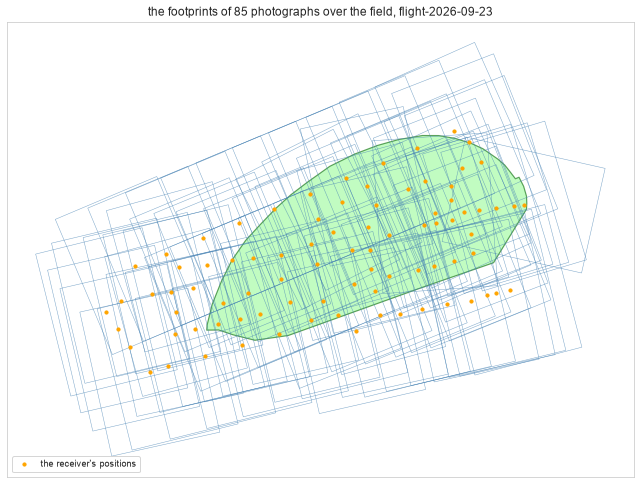

In [4]:
site = gpd.read_file("data/site.gpkg", layer="site").to_crs(choices["crs"])
field = site.geometry.iloc[0]
yaw = photos["flight_yaw_deg"].fillna(0.0)                                          # the aircraft's heading; the gimbal yaw column is zero on this aircraft
gsd_m = PIXEL_UM * 1e-6 * photos["rel_alt_m"] / (flight["focal_mm"] * 1e-3)         # metres per pixel on the ground, per photograph

footprints = []
for x, y, g, heading in zip(photos["easting"], photos["northing"], gsd_m, yaw):
    frame = box(x - W * g / 2, y - H * g / 2, x + W * g / 2, y + H * g / 2)          # the long side east to west before the turn
    footprints.append(rotate(frame, -heading, origin=(x, y)))                         # yaw runs clockwise from north, shapely turns anticlockwise

names = list(photos["file"])
shares = {}                                                                           # (earlier, later) to the overlap share
for i in range(len(footprints)):
    for j in range(i + 1, len(footprints)):
        shared = footprints[i].intersection(footprints[j]).area
        if shared > 0:
            shares[(names[i], names[j])] = shared / min(footprints[i].area, footprints[j].area)
predicted = reference["overlap"]["predicted_pairs"]
print(f"a footprint is {W * gsd_m.mean():.1f} by {H * gsd_m.mean():.1f} m on average   reference {reference['overlap']['footprint_m'][0]} by {reference['overlap']['footprint_m'][1]}")
print(f"the yaw is the aircraft's heading, which runs from {yaw.min():.1f} to {yaw.max():.1f} degrees; the gimbal yaw column runs from {photos['gimbal_yaw_deg'].min():.1f} to {photos['gimbal_yaw_deg'].max():.1f}")
print(f"pairs whose footprints overlap at all   {len(shares)}   reference {predicted['any']}")
print(f"by at least a fifth                     {sum(1 for s in shares.values() if s >= 0.2)}   reference {predicted['at_least_20_percent']}")
print(f"by at least a half                      {sum(1 for s in shares.values() if s >= 0.5)}   reference {predicted['at_least_50_percent']}")

fig, ax = plt.subplots(figsize=(9, 7.5))
gpd.GeoSeries(footprints, crs=choices["crs"]).boundary.plot(ax=ax, color="steelblue", linewidth=0.5, alpha=0.7)
site.plot(ax=ax, facecolor="palegreen", edgecolor="darkgreen", linewidth=1.2, alpha=0.6, zorder=0)
ax.scatter(photos["easting"], photos["northing"], s=10, color="orange", zorder=3, label="the receiver's positions")
ax.set_aspect("equal"); ax.legend(loc="lower left", fontsize=9); ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f"the footprints of {len(footprints)} photographs over the field, {flight['label']}", fontsize=12)
fig.tight_layout()

Compare the three counts. Any overlap at all is a weak thing, since two rectangles that touch at a corner share nothing worth matching; a fifth is where the software starts to have something to work with, and a half is a neighbouring photograph on the same leg or on the next one. The footprint on the first line is the size 03-03's arithmetic gives for this camera at this height, and the map shows how densely the flight stacked them over the field.

Then read the line about the yaw before you trust the map. The rectangles are turned by the aircraft's heading, and the range printed says how much that heading changed during the flight; beside it stands the gimbal's own yaw column, which on this aircraft deserves the same suspicion as its pitch, since a range of zero there is not a record of anything. A prediction from headings and positions is only a prediction, and the next section holds it against what the software actually matched.

## The pairs the software actually tried and matched

The software did not use our rectangles. It chose candidate pairs from the receiver's positions and from a graph of neighbours, matched features in every candidate, and kept the pairs where enough matches survived a geometric check, which 03b-03 does by hand. The kit carries every pair it considered in `pairs.csv`, with whether it was a candidate, how many robust matches it kept and how many tracks the two photographs share. Here are the counts, and the matched pairs drawn as lines between the camera positions, coloured by their matches:

candidate pairs the software tried   762   reference 762
pairs with robust matches            672   reference 672
edges of its view graph              1884   reference 1884
matched pairs the footprints predicted at a fifth or more   659 of 672   reference 659
matched pairs the footprints never predicted                0   reference 0
robust matches per matched pair, on average                 1120.1   reference 1120.1


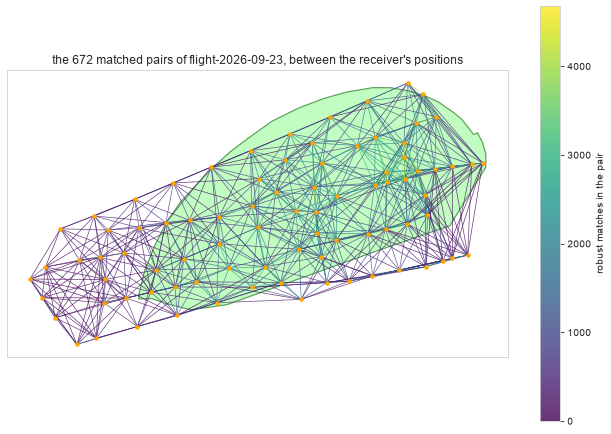

In [5]:
pairs = pd.read_csv("data/pairs.csv")
order = {n: i for i, n in enumerate(names)}
in_capture_order = lambda a, b: (a, b) if order.get(a, 0) <= order.get(b, 0) else (b, a)   # noqa: E731
matches_of = {in_capture_order(r.image_a, r.image_b): int(r.matches) for r in pairs.itertuples()}
matched = {p for p, m in matches_of.items() if m > 0}
predicted_20 = {p for p, s in shares.items() if s >= 0.2}
o = reference["overlap"]
print(f"candidate pairs the software tried   {int(pairs['candidate'].sum())}   reference {o['candidate_pairs']}")
print(f"pairs with robust matches            {len(matched)}   reference {o['matched_pairs']}")
print(f"edges of its view graph              {int((pairs['common_tracks'] > 0).sum())}   reference {o['view_graph_edges']}")
print(f"matched pairs the footprints predicted at a fifth or more   {len(matched & predicted_20)} of {len(matched)}   reference {o['matched_among_predicted_20']}")
print(f"matched pairs the footprints never predicted                {len(matched - set(shares))}   reference {o['matched_not_predicted']}")
print(f"robust matches per matched pair, on average                 {pairs.loc[pairs.matches > 0, 'matches'].mean():.1f}   reference {o['matches_per_pair_mean']}")

position = dict(zip(names, zip(photos["easting"], photos["northing"])))
drawn = sorted(matched, key=lambda p: matches_of[p])                                   # the strongest pairs drawn last, on top
segments = [[position[a], position[b]] for a, b in drawn if a in position and b in position]
strength = np.array([matches_of[p] for p in drawn if p[0] in position and p[1] in position])
fig, ax = plt.subplots(figsize=(9, 7.5))
site.plot(ax=ax, facecolor="palegreen", edgecolor="darkgreen", linewidth=1.2, alpha=0.6, zorder=0)
lines = LineCollection(segments, cmap="viridis", norm=Normalize(0, strength.max()), linewidths=0.7, alpha=0.8)
lines.set_array(strength); ax.add_collection(lines)
ax.scatter(photos["easting"], photos["northing"], s=12, color="orange", zorder=3)
fig.colorbar(lines, ax=ax, shrink=0.8, label="robust matches in the pair")
ax.autoscale(); ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f"the {len(segments)} matched pairs of {flight['label']}, between the receiver's positions", fontsize=12)
fig.tight_layout()

Read the three counts in order. The candidates are the pairs the software thought worth trying, chosen by position and by the neighbour graph rather than by any footprint; the matched pairs are the candidates where enough matches survived; and the view graph's edges are counted in tracks the two photographs share, and a track can join two photographs that were never matched directly, which is why that number can exceed the candidates. 03b-03 builds those tracks.

The two lines after them are the comparison this section is for. One says how many of the matched pairs the rectangles had predicted at a fifth or more, the other how many matched pairs had no predicted overlap at all. The two lists were made from different things, one from a formula and the file's positions, the other from the pictures themselves, and they nearly agree; where they differ, the rectangles were either too generous or turned the wrong way, and a pair the software matched without any predicted overlap is the map telling you the yaw was wrong. On the map the strong pairs are the short lines between neighbours on a leg, and the pale long lines are pairs across the field that share a few hundred matches, which is the sideways overlap 03-05 counted on.

## The software's own count of photographs per cell

The software also reports how many photographs saw each piece of ground, and the kit carries that map at its own resolution. It is not made from footprints. Every point of the dense cloud carries the number of photographs it was seen in, and each cell keeps the largest of those numbers among its points, so this is a count of what was matched rather than of what was flown:

the map has cells of 30 cm; 60% of them hold a count and the rest are outside the model
inside the field every cell was seen by 2 to 13 photographs, 8 in the middle; under the window's centre by 7


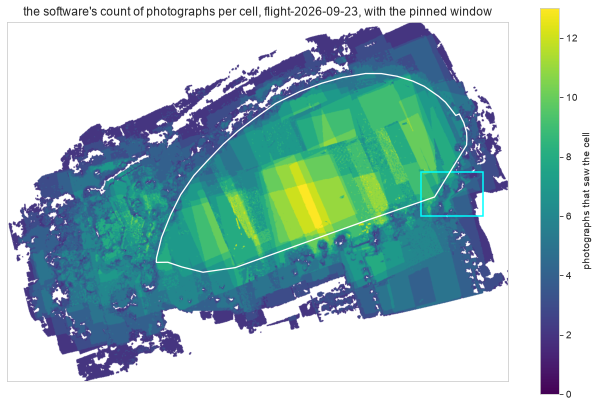

In [6]:
with rasterio.open("data/overlap_count.tif") as src:
    count = src.read(1)
    nodata = src.nodata
    extent = (src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top)
    inside = ~geometry_mask([site.to_crs(src.crs).geometry.iloc[0]], out_shape=count.shape, transform=src.transform)
    row, col = src.index(*choices["window"]["centre"])
    cell_m = src.res[0]
valid = count != nodata
in_field = count[inside & valid]
print(f"the map has cells of {cell_m * 100:.0f} cm; {valid.mean():.0%} of them hold a count and the rest are outside the model")
print(f"inside the field every cell was seen by {in_field.min()} to {in_field.max()} photographs, {np.median(in_field):.0f} in the middle; under the window's centre by {count[row, col]}")

b = choices["window"]["bounds"]
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(np.ma.masked_where(~valid, count), extent=extent, cmap="viridis", vmin=0)
site.to_crs(src.crs).boundary.plot(ax=ax, color="white", linewidth=1.3)
ax.add_patch(plt.Rectangle((b[0], b[1]), b[2] - b[0], b[3] - b[1], facecolor="none", edgecolor="cyan", linewidth=1.5))
fig.colorbar(im, ax=ax, shrink=0.8, label="photographs that saw the cell")
ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f"the software's count of photographs per cell, {flight['label']}, with the pinned window", fontsize=12)
fig.tight_layout()

This is the sibling of 03-05's coverage map, and the two are worth setting side by side. 03-05 counted footprints from the receiver's positions before the software had run, which is a promise; this map is the same question answered afterwards from the cloud the software built, which is a delivery. Read the minimum inside the field first, as 03-05 said, since two is the fewest photographs that give a height at all. Then read the map. The count is highest where the legs crossed or ran close together and thins toward the edge of the block, and the cyan rectangle is the window every later notebook works in, so the number under its centre says how many photographs the roof corner and the footpath junction had to be matched in.

## The rolling shutter

The sensor of this camera is read out line by line, not all at once, and while it is being read the aircraft moves. The software was told to allow for that, and 03-05 could only guess the readout time; the software's table carries the value it used. Here is what the movement costs in pixels, and what the correction cost in work:

In [7]:
readout_s = choices["readout_ms"] * 1e-3
shift_m = readout_s * flight["speed_m_s"]
shift_px = shift_m / gsd_m.mean()
sample_px = choices["sample_px"]
first_pass = np.mean(list(report["features_per_image"].values()))
final = report["stats"]["features_statistics"]["detected_features"]["mean"]
steps = report["stats"]["processing_statistics"]["steps_times"]
print(f"the readout takes {choices['readout_ms']} ms, and the software's table says {soft['rolling_shutter_ms']} ms; at {flight['speed_m_s']} m/s the aircraft moves {shift_m * 100:.1f} cm in that time")
print(f"that is {shift_px:.2f} pixels of the full frame between the first row and the last   reference {reference['overlap']['readout_shift_px']}")
print(f"at the kit's {sample_px} px it is {shift_px * sample_px / max(W, H):.2f} pixels")
print(f"the options   rolling_shutter {options['rolling_shutter']}, rolling_shutter_readout {options['rolling_shutter_readout']}, where zero means the software's own table of cameras")
print(f"features per photograph   {first_pass:.0f} in the first pass, {final:.0f} in the final statistics   reference {reference['features']['per_photograph']['mean']}")
print("the four steps of the final pass   " + ", ".join(f"{k.lower()} {v:.0f} s" for k, v in steps.items() if k != "Total Time") + f"; the whole stage took {report['benchmark_s']['opensfm']:.0f} s")

the readout takes 23.0 ms, and the software's table says 23.0 ms; at 4.69 m/s the aircraft moves 10.8 cm in that time
that is 3.81 pixels of the full frame between the first row and the last   reference 3.81
at the kit's 2000 px it is 1.90 pixels
the options   rolling_shutter True, rolling_shutter_readout 0, where zero means the software's own table of cameras
features per photograph   9982 in the first pass, 4629 in the final statistics   reference 4629.0
the four steps of the final pass   feature extraction 45 s, features matching 26 s, tracks merging 5 s, reconstruction 89 s; the whole stage took 0 s


Read the shift in pixels of the full frame. A few pixels is small against a frame of thousands, but it is a systematic error rather than a random one, since every row of every photograph is displaced by a little more than the row above it, in the direction of flight, and an adjustment that does not know this will bend the block to absorb it. So the software was told, and it did something expensive about it. It solved the block once with the features as found, used the cameras' speeds from that solution to correct every feature's position, and solved the block again. The count of features per photograph in the report's first pass and in its final statistics are two different numbers, which is the mark of the correction between the two solves, and the stage's total time is well beyond what the four steps of the final pass add up to, which is where the first solve and the undistortion of every photograph went. At the kit's size the shift is under a pixel, and it matters only at the frame's edge, which is why nothing we do by hand in the notebooks that follow needs to correct for it.

## The unknowns before any point

Everything above is what the software knew before it had matched anything. Count what it still had to find:

In [8]:
n = flight["n_photos"]
print(f"{n} photographs times six, three for where and three for which way, is {6 * n} unknowns")
print(f"plus the camera's eight, the focal length, two for the principal point, three radial and two tangential distortion terms, is {6 * n + 8}   reference {reference['overlap']['unknowns_before_points']}")
print(f"the software's table holds {len(exif)} photographs, so no file was refused at this stage")

85 photographs times six, three for where and three for which way, is 510 unknowns
plus the camera's eight, the focal length, two for the principal point, three radial and two tangential distortion terms, is 518   reference 518
the software's table holds 85 photographs, so no file was refused at this stage


Six unknowns per photograph, the exterior orientation of the lecture, plus one camera shared by all of them, because one lens took every picture. Nothing in the files above fixes any of these to better than the receiver's metres and the assumed vertical; the priors are starting guesses. What fixes them are observations, a feature seen in two or more photographs giving two equations per sighting, and every observation also brings a point in space with three unknowns of its own. 03b-03 finds the observations, and 03b-04 counts the points and the equations and shows that the equations win by a wide margin, which is what makes the adjustment possible.

## Your turn

From the footprints alone, name the pair of photographs that should match best, the one whose rectangles overlap by the largest share, and then check in the software's table how many robust matches that pair actually got and whether it was a candidate at all. Say in a sentence whether the geometry's favourite was also the software's.

The cell below has the lines with blanks. Fill them, remove the `#` at the start of each line, and run it. There is no class answer on the board.

In [9]:
# Your attempt. shares maps a pair of names in capture order to the share of the smaller footprint the two overlap by, and matches_of maps the same kind of pair to the software's robust matches.
#
# best = max(shares, key=___)                                    # the pair with the largest share
# print(f"{best[0]} and {best[1]} overlap by {shares[best]:.0%} of the smaller footprint")
# print(f"the software kept {matches_of.get(best, ___)} robust matches between them")

## Check your understanding

1. The software's focal prior is the 35 mm equivalent over 36 and 03-03's is the focal length over the pixel pitch, and they differ by several percent for one lens. Explain where each number comes from, and say why neither of them is the focal length the block will end up with.
2. The software's table carries omega, phi and kappa for every photograph, and it ignored them. Give the reason in one sentence, and name the assumption it made instead.
3. Say what a candidate pair is, how the software chose its candidates without any footprint, and why the view graph can have more edges than there were candidates.
4. The sensor is read out line by line while the aircraft moves. Say what that does to a photograph of the ground, why it is worse for an adjustment than a random error of the same size, and what the software did about it.

## Where we are

You can open the software's own reading of the photographs and compare it with what 03-05 read from the same files. You know that it built its camera from the 35 mm equivalent, that it assumed every camera looked straight down and trusted the receiver to a few metres, and that these are priors an adjustment will move. You have predicted the overlap of the block from rectangles and held the prediction against the pairs the software matched, read its count of photographs per cell as the delivered version of 03-05's promise, priced the rolling shutter in pixels, and counted the unknowns a block starts with.

The habit worth keeping: before you trust a model, read what the software read, because every prior it started from and every pair it never tried is written down somewhere, and the metadata is where a wrong camera or a wrong heading is cheapest to find.

In 03b-02 we look inside one photograph and find what the software will match.

## Further resources

Nothing in this course requires anything below.

OpenDroneMap's documentation explains the accuracy it assumes for the receiver, the rolling shutter correction and its table of cameras, and how it chooses the pairs to match: https://docs.opendronemap.org/arguments/gps-accuracy/, https://docs.opendronemap.org/arguments/rolling-shutter/, https://docs.opendronemap.org/arguments/matcher-neighbors/. The structure from motion inside it is OpenSfM, whose documentation describes the camera models, the normalised image coordinates and the pipeline the next notebooks follow: https://opensfm.org/docs/

Szeliski's Computer Vision, free online, covers image formation and camera models in chapter 2 and structure from motion in chapter 11: https://szeliski.org/Book/. The photogrammetric account of interior and exterior orientation is Wolf, Dewitt and Wilkinson, Elements of Photogrammetry with Applications in GIS, 4th edition, McGraw-Hill, 2014.

The photographs, the tables and the software's report are the course's own flight, published under CC BY 4.0. The outline of Poe Field is an OpenStreetMap extract, licensed ODbL 1.0, copyright OpenStreetMap contributors: https://www.openstreetmap.org/copyright

## Appendix, in case you are stuck

Try properly first. If you do use these, treat them the way you would treat an agent's answer. Read them, run them, and say why yours differed.

The pair with the largest overlap share and the matches the software kept for it, recomputed from the tables so that the cell stands on its own:

```python
import json
import pandas as pd
from shapely.geometry import box
from shapely.affinity import rotate

flight = json.load(open("data/flight.json"))
photos = pd.read_csv("data/photos.csv")
pairs = pd.read_csv("data/pairs.csv")
width, height = flight["image_px"]
yaw = photos["flight_yaw_deg"].fillna(0.0)
gsd_m = 2.4e-6 * photos["rel_alt_m"] / (flight["focal_mm"] * 1e-3)
footprints = [rotate(box(x - width * g / 2, y - height * g / 2, x + width * g / 2, y + height * g / 2), -h, origin=(x, y))
              for x, y, g, h in zip(photos["easting"], photos["northing"], gsd_m, yaw)]
names = list(photos["file"])
shares = {}
for i in range(len(footprints)):
    for j in range(i + 1, len(footprints)):
        shared = footprints[i].intersection(footprints[j]).area
        if shared > 0:
            shares[(names[i], names[j])] = shared / min(footprints[i].area, footprints[j].area)
best = max(shares, key=shares.get)
row = pairs[((pairs.image_a == best[0]) & (pairs.image_b == best[1])) | ((pairs.image_a == best[1]) & (pairs.image_b == best[0]))]
print(f"{best[0]} and {best[1]} overlap by {shares[best]:.0%} of the smaller footprint")
print(f"the software kept {int(row['matches'].iloc[0]) if len(row) else 0} robust matches between them, candidate {int(row['candidate'].iloc[0]) if len(row) else 0}")
```

If the winning pair overlaps by nearly the whole footprint, the aircraft was almost standing still between the two exposures, at a turn or at the start of a leg. Such a pair matches very well and is worth very little, because two photographs from the same place give no parallax and therefore no height, which is why 03b-03 chooses its pair by matches and a minimum baseline rather than by matches alone.